Sample rate : 16000 Hz
Number of samples: 16000
Duration: 1.00 seconds


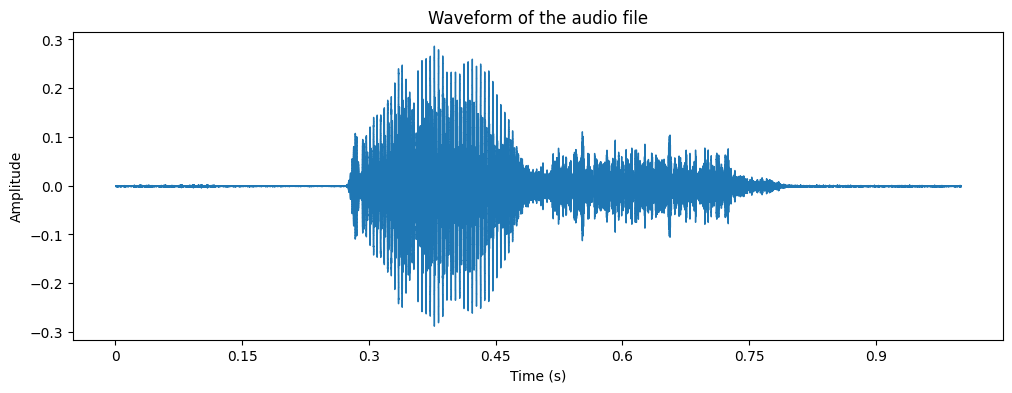

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf # Alternative to librosa .load for direct access to audio data
from IPython.display import Audio

# Path to a sample file (adjust)
audio_file_path = 'speech_commands_v0.02/yes/0a7c2a8d_nohash_0.wav'

# Loading the audio file
# audio_data, sample_rate = librosa.load(audio_file_path, sr=None) # sr=None to keep the original sample rate
audio_data, sample_rate = sf.read(audio_file_path) # Alternative for pure data access
print(f"Sample rate : {sample_rate} Hz")
print(f"Number of samples: {len(audio_data)}")
print(f"Duration: {len(audio_data) / sample_rate:.2f} seconds")

# Visualize waveform
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y=audio_data, sr=sample_rate)
plt.title('Waveform of the audio file')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

# Play audio file (if in Jupyter Notebook)
Audio(data=audio_data, rate=sample_rate)

In [5]:
def extract_mfccs(audio_path, sr=16000, n_mfcc=256, n_fft=4096, hop_length=512):
    """ Extracts MFCCs from an audio file.
    Args:
    audio_path (str): Path to the audio file.
    sr (int): Target sampling rate (default: 16000 Hz for speech commands).
    n_mfcc (int): Number of MFCCs to extract.
    n_fft (int): Size of the FFT window.
    hop_length (int): Step size between consecutive frames.

    Returns:
    numpy.ndarray: Array of MFCCs (shape: n_mfcc, number_of_frames).

    saved file names convention:
    Figure1_yes_sr16000_n_mfcc13_n_fft2048_hop_length512.png
    """

    audio, _ = librosa.load(audio_path, sr=sr) 

    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length) 
    return mfccs


In [6]:
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

import joblib

import librosa
import numpy as np
import soundfile as sf # Alternative to librosa.load for direct access to audio data

# Main directory of the dataset (adjust)
data_dir = 'speech_commands_v0.02'

def prepare_dataset_scikit_learn(data_directory, sr=16000, n_mfcc=13):
    X = [] # Features (MFCCs)
    y = [] # Labels
    allowed_words = ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go']
    # You can also add _background_noise_ and _unknown_
    for root, _, files in os.walk(data_directory):
        for file in files:
            if file.endswith('.wav'):
                label = os.path.basename(root)
                if label in allowed_words:
                    file_path = os.path.join(root, file)
                    try:
                        mfccs = extract_mfccs(file_path, sr=sr, n_mfcc=n_mfcc)
                        # For scikit-learn: Average MFCCs over time
                        mfccs_mean = np.mean(mfccs, axis=1)
                        X.append(mfccs_mean)
                        y.append(label)
                    except Exception as e:
                        print(f"Error processing {file_path}: {e}")

    # Convert to numpy arrays after collecting all files
    X = np.array(X)
    y = np.array(y)

    if X.size == 0:
        raise ValueError(f"No audio samples found in {data_directory}")

    # Convert labels to numeric values
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    # If we only have a single sample, return it as the training set and empty others
    if len(X) == 1:
        X_train = X
        y_train = y_encoded
        n_features = X.shape[1] if X.ndim == 2 else 1
        X_val = np.empty((0, n_features))
        X_test = np.empty((0, n_features))
        y_val = np.empty((0,), dtype=y_encoded.dtype)
        y_test = np.empty((0,), dtype=y_encoded.dtype)
        return X_train, X_val, X_test, y_train, y_val, y_test, label_encoder

    # First split: train vs (val+test)
    try:
        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
        )
    except ValueError:
        # Fallback to non-stratified split when stratification is not possible
        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y_encoded, test_size=0.3, random_state=42, stratify=None
        )

    # If there is 0 or 1 sample left in X_temp, assign appropriately
    if len(X_temp) == 0:
        print("Lenght of X_temp == 0. Assign appropriately")
        n_features = X.shape[1] if X.ndim == 2 else 1
        X_val = np.empty((0, n_features))
        X_test = np.empty((0, n_features))
        y_val = np.empty((0,), dtype=y_encoded.dtype)
        y_test = np.empty((0,), dtype=y_encoded.dtype)
        return X_train, X_val, X_test, y_train, y_val, y_test, label_encoder

    if len(X_temp) == 1:
        # Put the single remaining sample into validation and leave test empty
        print("Lenght of X_temp == 1.")
        X_val = X_temp
        y_val = y_temp
        n_features = X.shape[1] if X.ndim == 2 else 1
        X_test = np.empty((0, n_features))
        y_test = np.empty((0,), dtype=y_encoded.dtype)
        return X_train, X_val, X_test, y_train, y_val, y_test, label_encoder

    # Split the temporary set into validation and test
    try:
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
        )
    except ValueError:
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp, test_size=0.5, random_state=42, stratify=None
        )

    return X_train, X_val, X_test, y_train, y_val, y_test, label_encoder

print("Prepare data for scikit-learn...")
X_train_sk, X_val_sk, X_test_sk, y_train_sk, y_val_sk, y_test_sk, label_encoder_sk = prepare_dataset_scikit_learn(data_dir)

print(f"Training data Shape (scikit-learn): {X_train_sk.shape}, Labels: {y_train_sk.shape}")
print(f"Validation data Shape (scikit-learn): {X_val_sk.shape}, Labels: {y_val_sk.shape}")
print(f"Test Data Shape (scikit-learn): {X_test_sk.shape}, Labels: {y_test_sk.shape}")
print(f"Classes: {label_encoder_sk.classes_}")

Prepare data for scikit-learn...


KeyboardInterrupt: 

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib # Needed to save the model as per instructions

# ==========================================================
# Example: Training a Support Vector Machine (SVC)
# ==========================================================
print("\nTraining an SVC model (scikit-learn)... ")
svm_model = SVC(kernel='rbf', C=10) # Experiment with Kernel and C
svm_model.fit(X_train_sk, y_train_sk)

# Evaluation
y_pred_svm = svm_model.predict(X_test_sk)
print("SVC Classification Report:")
print(classification_report(y_test_sk, y_pred_svm, 
                            target_names=label_encoder_sk.classes_))
print(f"SVC Accuracy on Test Data: {accuracy_score(y_test_sk, y_pred_svm):.4f}")

# Save the model
joblib.dump(svm_model, 'svm_model.joblib')


# ==========================================================
# Example: Training a Random Forest Classifier
# ==========================================================
print("\nTraining a Random Forest Model (scikit-learn)... ")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) # Experiment with n_estimators
rf_model.fit(X_train_sk, y_train_sk)

# Evaluation
y_pred_rf = rf_model.predict(X_test_sk)
print("Random Forest Classification Report:")
print(classification_report(y_test_sk, y_pred_rf, 
                            target_names=label_encoder_sk.classes_))
print(f"Random Forest Accuracy on Test data: {accuracy_score(y_test_sk, y_pred_rf):.4f}")

# Save the model
joblib.dump(rf_model, 'rf_model.joblib')